In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

data = pd.read_csv("car_brand_data.csv")
data.head()

,Brand,Parent,Country,Luxury
0,Acura,Honda Motor Company,Japan,Yes
1,Alfa Romeo,Stellantis,Italy,Yes
2,Audi,Volkswagen Group,Germany,Yes
3,BMW,BMW Group,Germany,Yes
4,Bentley,Volkswagen Group,UK,Yes


In [2]:
print(data.shape)
print(data.columns)

(37, 4)
Index(['Brand', 'Parent', 'Country', 'Luxury'], dtype='object')


In [5]:
# Bipartite Graph:
B = nx.Graph()

for i in range(len(data)):
    parent = data.loc[i, "Parent"]
    brand = data.loc[i, "Brand"]
    country = data.loc[i, "Country"]
    luxury = data.loc[i, "Luxury"]

    B.add_node(parent, node_type="parent")
    B.add_node(brand, node_type="brand", country=country, luxury=luxury)
    B.add_edge(parent, brand)

print("Number of nodes:", B.number_of_nodes())
print("Number of edges:", B.number_of_edges())

Number of nodes: 51
Number of edges: 37


In [6]:
parent_nodes = []
brand_nodes = []

for node, info in B.nodes(data=True):
    if info["node_type"] == "parent":
        parent_nodes.append(node)
    else:
        brand_nodes.append(node)

print("Parent companies:", parent_nodes)
print("Brands:", brand_nodes)

Parent companies: ['Honda Motor Company', 'Stellantis', 'Volkswagen Group', 'BMW Group', 'General Motors', 'Ford Motor Company', 'Hyundai Motor Group', 'Tata Motors', 'Nissan Motor Company', 'Toyota Motor Corporation', 'Mazda Motor Corporation', 'Mitsubishi Motors', 'Subaru Corporation', 'Tesla Inc']
Brands: ['Acura', 'Alfa Romeo', 'Audi', 'BMW', 'Bentley', 'Bugatti', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Dodge', 'Fiat', 'Ford', 'GMC', 'Genesis', 'Honda', 'Hyundai', 'Jaguar', 'Infiniti', 'Jeep', 'Kia', 'Lexus', 'Lamborghini', 'Lincoln', 'Maserati', 'Mazda', 'Mercury', 'Mini', 'Mitsubishi', 'Nissan', 'Porsche', 'RAM', 'Range Rover', 'Rolls-Royce', 'Subaru', 'Tesla', 'Volkswagen']


In [11]:
# Finding Biggest Hubs
for parent in parent_degree:
    print(parent, ":", parent_degree[parent])

Honda Motor Company : 2
Stellantis : 7
Volkswagen Group : 6
BMW Group : 3
General Motors : 4
Ford Motor Company : 3
Hyundai Motor Group : 3
Tata Motors : 2
Nissan Motor Company : 2
Toyota Motor Corporation : 1
Mazda Motor Corporation : 1
Mitsubishi Motors : 1
Subaru Corporation : 1
Tesla Inc : 1


In [12]:
max_parent = max(parent_degree, key=parent_degree.get)

print("Largest parent company:", max_parent)
print("Number of brands:", parent_degree[max_parent])

Largest parent company: Stellantis
Number of brands: 7


In [13]:
sorted_parents = sorted(parent_degree.items(), key=lambda x: x[1], reverse=True)

for item in sorted_parents:
    print(item[0], ":", item[1])

Stellantis : 7
Volkswagen Group : 6
General Motors : 4
BMW Group : 3
Ford Motor Company : 3
Hyundai Motor Group : 3
Honda Motor Company : 2
Tata Motors : 2
Nissan Motor Company : 2
Toyota Motor Corporation : 1
Mazda Motor Corporation : 1
Mitsubishi Motors : 1
Subaru Corporation : 1
Tesla Inc : 1


<Figure size 1000x500 with 0 Axes>

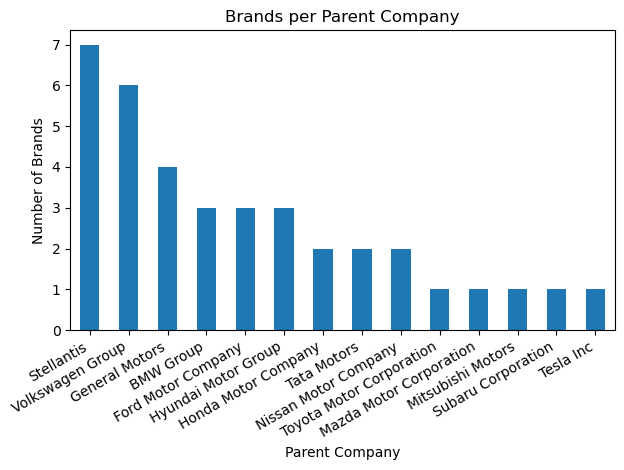

In [17]:
plt.figure(figsize=(10,5))

parent_table = parent_table.sort_values(by="Degree", ascending=False)
parent_table.plot(x="Parent", y="Degree", kind="bar", legend=False)

plt.xticks(rotation=30, ha="right")
plt.title("Brands per Parent Company")
plt.ylabel("Number of Brands")
plt.xlabel("Parent Company")

plt.tight_layout()
plt.show()

In [20]:
G = nx.bipartite.projected_graph(B, brand_nodes)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 37
Number of edges: 54


In [19]:
sorted_brands = sorted(brand_degree.items(), key=lambda x: x[1], reverse=True)

for item in sorted_brands:
    print(item[0], ":", item[1])

brand_table = pd.DataFrame(sorted_brands, columns=["Brand", "Degree"])
print(brand_table)

Alfa Romeo : 6
Chrysler : 6
Dodge : 6
Fiat : 6
Jeep : 6
Maserati : 6
RAM : 6
Audi : 5
Bentley : 5
Bugatti : 5
Lamborghini : 5
Porsche : 5
Volkswagen : 5
Buick : 3
Cadillac : 3
Chevrolet : 3
GMC : 3
BMW : 2
Ford : 2
Genesis : 2
Hyundai : 2
Kia : 2
Lincoln : 2
Mercury : 2
Mini : 2
Rolls-Royce : 2
Acura : 1
Honda : 1
Jaguar : 1
Infiniti : 1
Nissan : 1
Range Rover : 1
Lexus : 0
Mazda : 0
Mitsubishi : 0
Subaru : 0
Tesla : 0
          Brand  Degree
0    Alfa Romeo       6
1      Chrysler       6
2         Dodge       6
3          Fiat       6
4          Jeep       6
5      Maserati       6
6           RAM       6
7          Audi       5
8       Bentley       5
9       Bugatti       5
10  Lamborghini       5
11      Porsche       5
12   Volkswagen       5
13        Buick       3
14     Cadillac       3
15    Chevrolet       3
16          GMC       3
17          BMW       2
18         Ford       2
19      Genesis       2
20      Hyundai       2
21          Kia       2
22      Lincoln       2
2

In [21]:
degree_centrality = nx.degree_centrality(G)

for brand in degree_centrality:
    print(brand, ":", degree_centrality[brand])

Acura : 0.027777777777777776
Alfa Romeo : 0.16666666666666666
Audi : 0.1388888888888889
BMW : 0.05555555555555555
Bentley : 0.1388888888888889
Bugatti : 0.1388888888888889
Buick : 0.08333333333333333
Cadillac : 0.08333333333333333
Chevrolet : 0.08333333333333333
Chrysler : 0.16666666666666666
Dodge : 0.16666666666666666
Fiat : 0.16666666666666666
Ford : 0.05555555555555555
GMC : 0.08333333333333333
Genesis : 0.05555555555555555
Honda : 0.027777777777777776
Hyundai : 0.05555555555555555
Jaguar : 0.027777777777777776
Infiniti : 0.027777777777777776
Jeep : 0.16666666666666666
Kia : 0.05555555555555555
Lexus : 0.0
Lamborghini : 0.1388888888888889
Lincoln : 0.05555555555555555
Maserati : 0.16666666666666666
Mazda : 0.0
Mercury : 0.05555555555555555
Mini : 0.05555555555555555
Mitsubishi : 0.0
Nissan : 0.027777777777777776
Porsche : 0.1388888888888889
RAM : 0.16666666666666666
Range Rover : 0.027777777777777776
Rolls-Royce : 0.05555555555555555
Subaru : 0.0
Tesla : 0.0
Volkswagen : 0.13888888

In [22]:
betweenness = nx.betweenness_centrality(G)

for brand in betweenness:
    print(brand, ":", betweenness[brand])

Acura : 0.0
Alfa Romeo : 0.0
Audi : 0.0
BMW : 0.0
Bentley : 0.0
Bugatti : 0.0
Buick : 0.0
Cadillac : 0.0
Chevrolet : 0.0
Chrysler : 0.0
Dodge : 0.0
Fiat : 0.0
Ford : 0.0
GMC : 0.0
Genesis : 0.0
Honda : 0.0
Hyundai : 0.0
Jaguar : 0.0
Infiniti : 0.0
Jeep : 0.0
Kia : 0.0
Lexus : 0.0
Lamborghini : 0.0
Lincoln : 0.0
Maserati : 0.0
Mazda : 0.0
Mercury : 0.0
Mini : 0.0
Mitsubishi : 0.0
Nissan : 0.0
Porsche : 0.0
RAM : 0.0
Range Rover : 0.0
Rolls-Royce : 0.0
Subaru : 0.0
Tesla : 0.0
Volkswagen : 0.0


In [23]:
clustering = nx.clustering(G)

for brand in clustering:
    print(brand, ":", clustering[brand])

Acura : 0
Alfa Romeo : 1.0
Audi : 1.0
BMW : 1.0
Bentley : 1.0
Bugatti : 1.0
Buick : 1.0
Cadillac : 1.0
Chevrolet : 1.0
Chrysler : 1.0
Dodge : 1.0
Fiat : 1.0
Ford : 1.0
GMC : 1.0
Genesis : 1.0
Honda : 0
Hyundai : 1.0
Jaguar : 0
Infiniti : 0
Jeep : 1.0
Kia : 1.0
Lexus : 0
Lamborghini : 1.0
Lincoln : 1.0
Maserati : 1.0
Mazda : 0
Mercury : 1.0
Mini : 1.0
Mitsubishi : 0
Nissan : 0
Porsche : 1.0
RAM : 1.0
Range Rover : 0
Rolls-Royce : 1.0
Subaru : 0
Tesla : 0
Volkswagen : 1.0


In [24]:
results = pd.DataFrame({
    "Brand": list(G.nodes()),
    "Degree Centrality": [degree_centrality[brand] for brand in G.nodes()],
    "Betweenness Centrality": [betweenness[brand] for brand in G.nodes()],
    "Clustering Coefficient": [clustering[brand] for brand in G.nodes()]
})

results = results.sort_values(by="Degree Centrality", ascending=False)

print(results)

          Brand  Degree Centrality  Betweenness Centrality  \
10        Dodge           0.166667                     0.0   
9      Chrysler           0.166667                     0.0   
1    Alfa Romeo           0.166667                     0.0   
31          RAM           0.166667                     0.0   
24     Maserati           0.166667                     0.0   
11         Fiat           0.166667                     0.0   
19         Jeep           0.166667                     0.0   
5       Bugatti           0.138889                     0.0   
30      Porsche           0.138889                     0.0   
4       Bentley           0.138889                     0.0   
22  Lamborghini           0.138889                     0.0   
2          Audi           0.138889                     0.0   
36   Volkswagen           0.138889                     0.0   
7      Cadillac           0.083333                     0.0   
8     Chevrolet           0.083333                     0.0   
6       

In [25]:
nx.write_gexf(G, "car_brands_projected.gexf")

In [26]:
import os
print(os.getcwd())

/Users/nathaliachimbay/Documents
